In [4]:
%pip install brian2 brian2hears librosa numpy scipy matplotlib
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Bezig met verwerken van: data/stimuli/stimuli_1/audiobook_1_1.wav...
Succes! Lengte van envelope: 1280 samples.


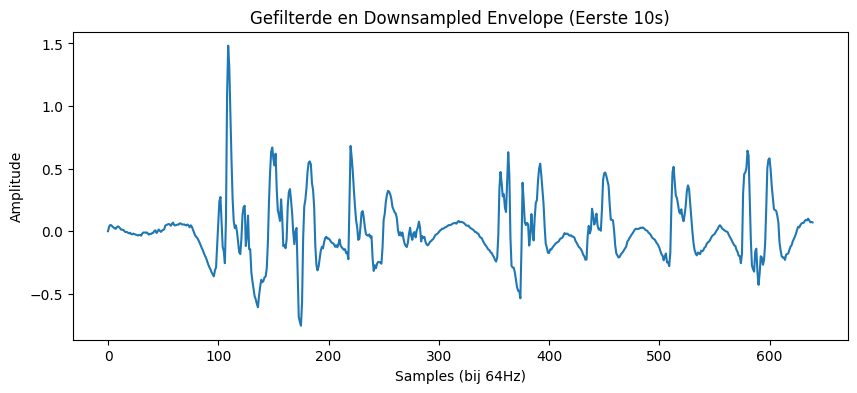

In [3]:
import logging
logging.getLogger('brian2').setLevel(logging.ERROR)

import brian2
brian2.prefs.codegen.target = 'numpy'

from brian2 import Hz, kHz
from brian2hears import Sound, erbspace, Gammatone, Filterbank
from scipy import signal
import librosa
import numpy as np
import matplotlib.pyplot as plt
from math import gcd 

class EnvelopeFromGammatoneFilterbank(Filterbank):
    """Converts the output of a GammatoneFilterbank to an envelope."""

    def __init__(self, source):
        super().__init__(source)
        self.nchannels = 1

    def buffer_apply(self, input_):
        # 6. take absolute value of the input_
        abs_input = np.abs(input_)
        # 7. power-law compression (exponent 0.6)
        compressed = abs_input ** 0.6
        # 8. linearly combine by summing the subbands
        envelope = np.sum(compressed, axis=1, keepdims=True) 
        return envelope

def process_audio_file(wav_filename, target_sr=64, lowcut=1.0, highcut=32.0):
    print(f"Bezig met verwerken van: {wav_filename}...")
    
    # 1. LOAD THE AUDIO FILE
    audio_data, sr = librosa.load(wav_filename, sr=None, mono=True, duration=20)

    # 2. convert the audio file to a brian sound object
    sound = Sound(audio_data.reshape(-1, 1), samplerate=sr*Hz)

    # 3. 28 center frequencies between 50 Hz and 5 kHz
    cf = erbspace(50*Hz, 5*kHz, 28)

    # 4. create the gammatone filterbank
    gammatone_filterbank = Gammatone(sound, cf)

    # 5. process envelope
    envelope_calcuation = EnvelopeFromGammatoneFilterbank(gammatone_filterbank)
    envelope = envelope_calcuation.process()
    envelope = envelope.flatten() 

    # 6. Bandpass filter instellen (1-32 Hz)
    sos = signal.butter(N=4, Wn=[lowcut, highcut], btype='bandpass', fs=sr, output='sos')
    envelope_filtered = signal.sosfiltfilt(sos, envelope)

    # 7. Downsample de resulterende signalen naar 64Hz
    g = gcd(int(sr), target_sr)
    envelope_downsampled = signal.resample_poly(envelope_filtered, target_sr // g, int(sr) // g)
    
    return envelope_downsampled

test_audio = "data/stimuli/stimuli_1/audiobook_1_1.wav"

try:
    env = process_audio_file(test_audio)
    print(f"Succes! Lengte van envelope: {len(env)} samples.")
    
    # Visuele check: plot de eerste 10 seconden (10 * 64 Hz = 640 samples)
    plt.figure(figsize=(10, 4))
    plt.plot(env[:640])
    plt.title("Gefilterde en Downsampled Envelope (Eerste 10s)")
    plt.xlabel("Samples (bij 64Hz)")
    plt.ylabel("Amplitude")
    plt.show()
    
except Exception as e:
    print(f"Oei, er ging iets mis: {e}")
